### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [142]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
import seaborn as sns
import graphviz as graph

%matplotlib inline

sns.set_style("white")


In [143]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams['figure.dpi'] = 300

In [144]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import export_graphviz 

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [145]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [146]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [147]:
LearningSet["P_HABITABLE"].value_counts()

P_HABITABLE
0    10
1     8
Name: count, dtype: int64

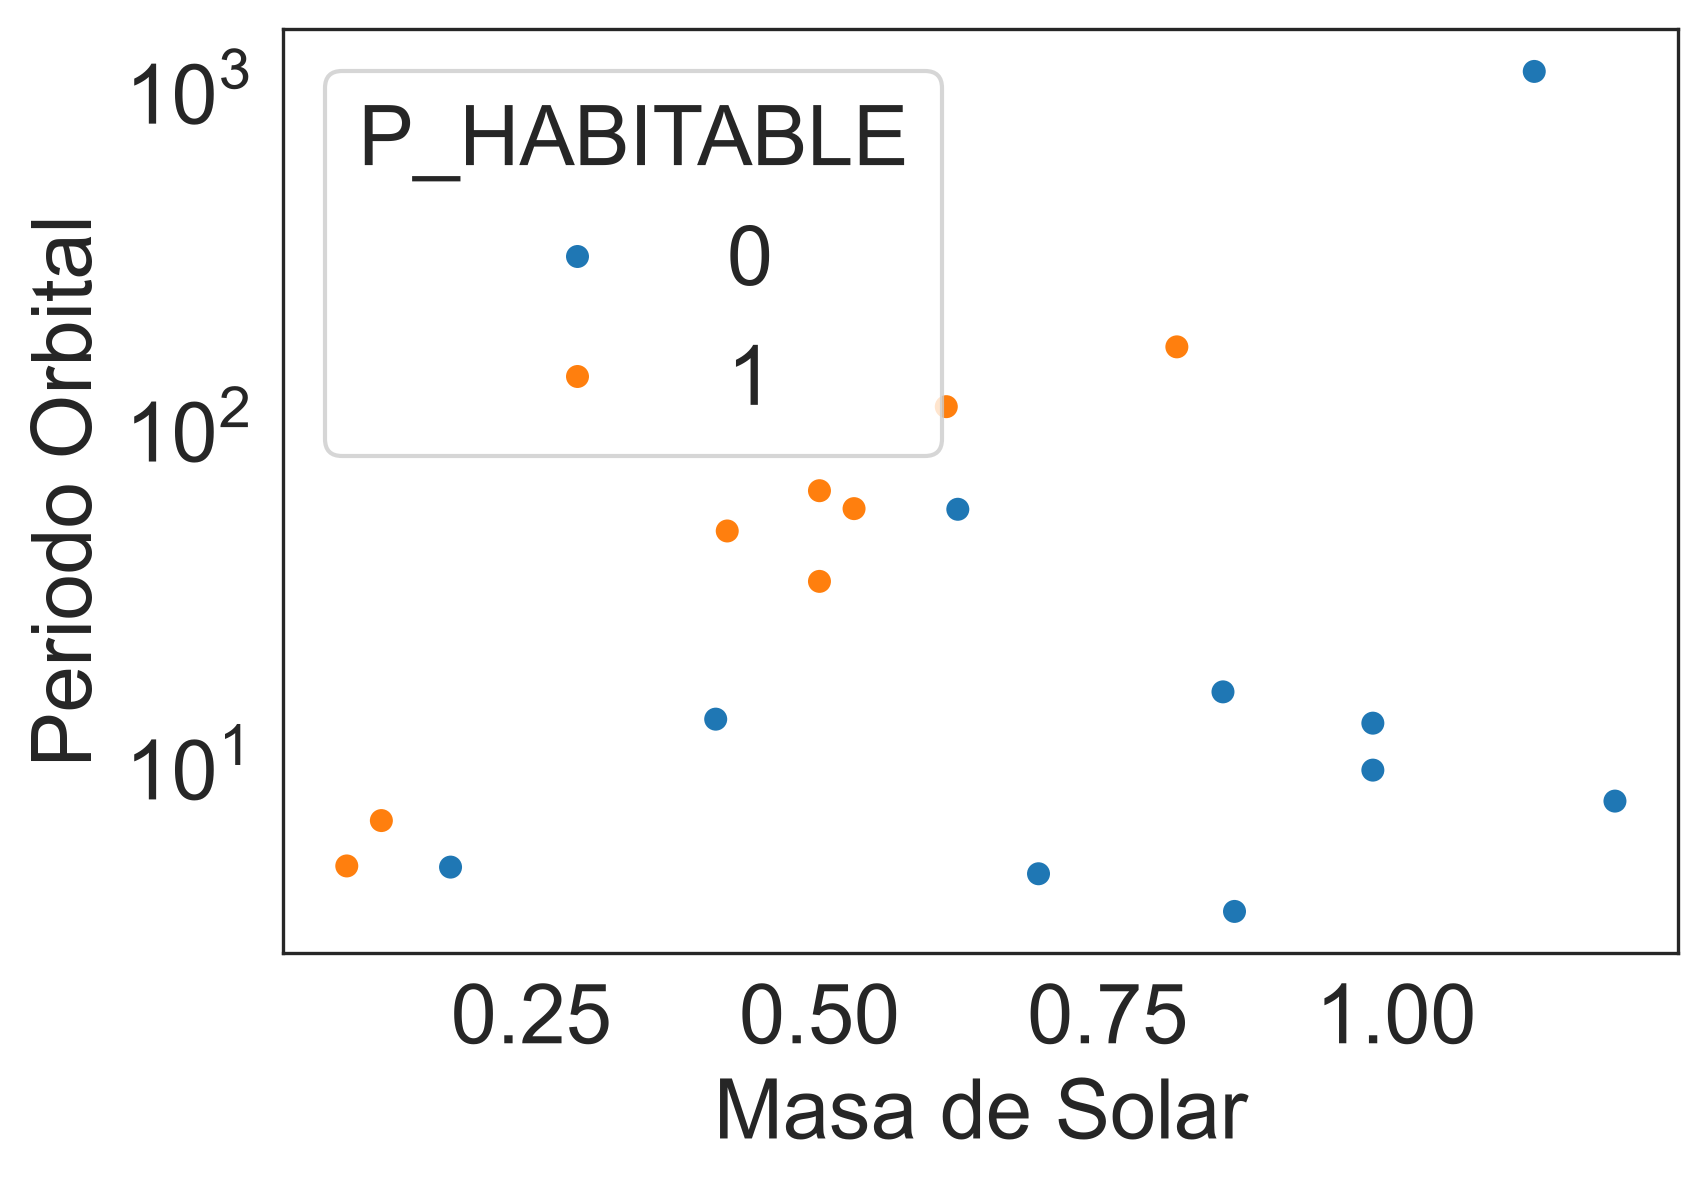

In [148]:

plt.figure(figsize=(6,4))

sns.scatterplot(data=LearningSet, x="S_MASS", y="P_PERIOD", hue="P_HABITABLE")

plt.yscale("log")

plt.xlabel("Masa de Solar")
plt.ylabel("Periodo Orbital")

plt.show()

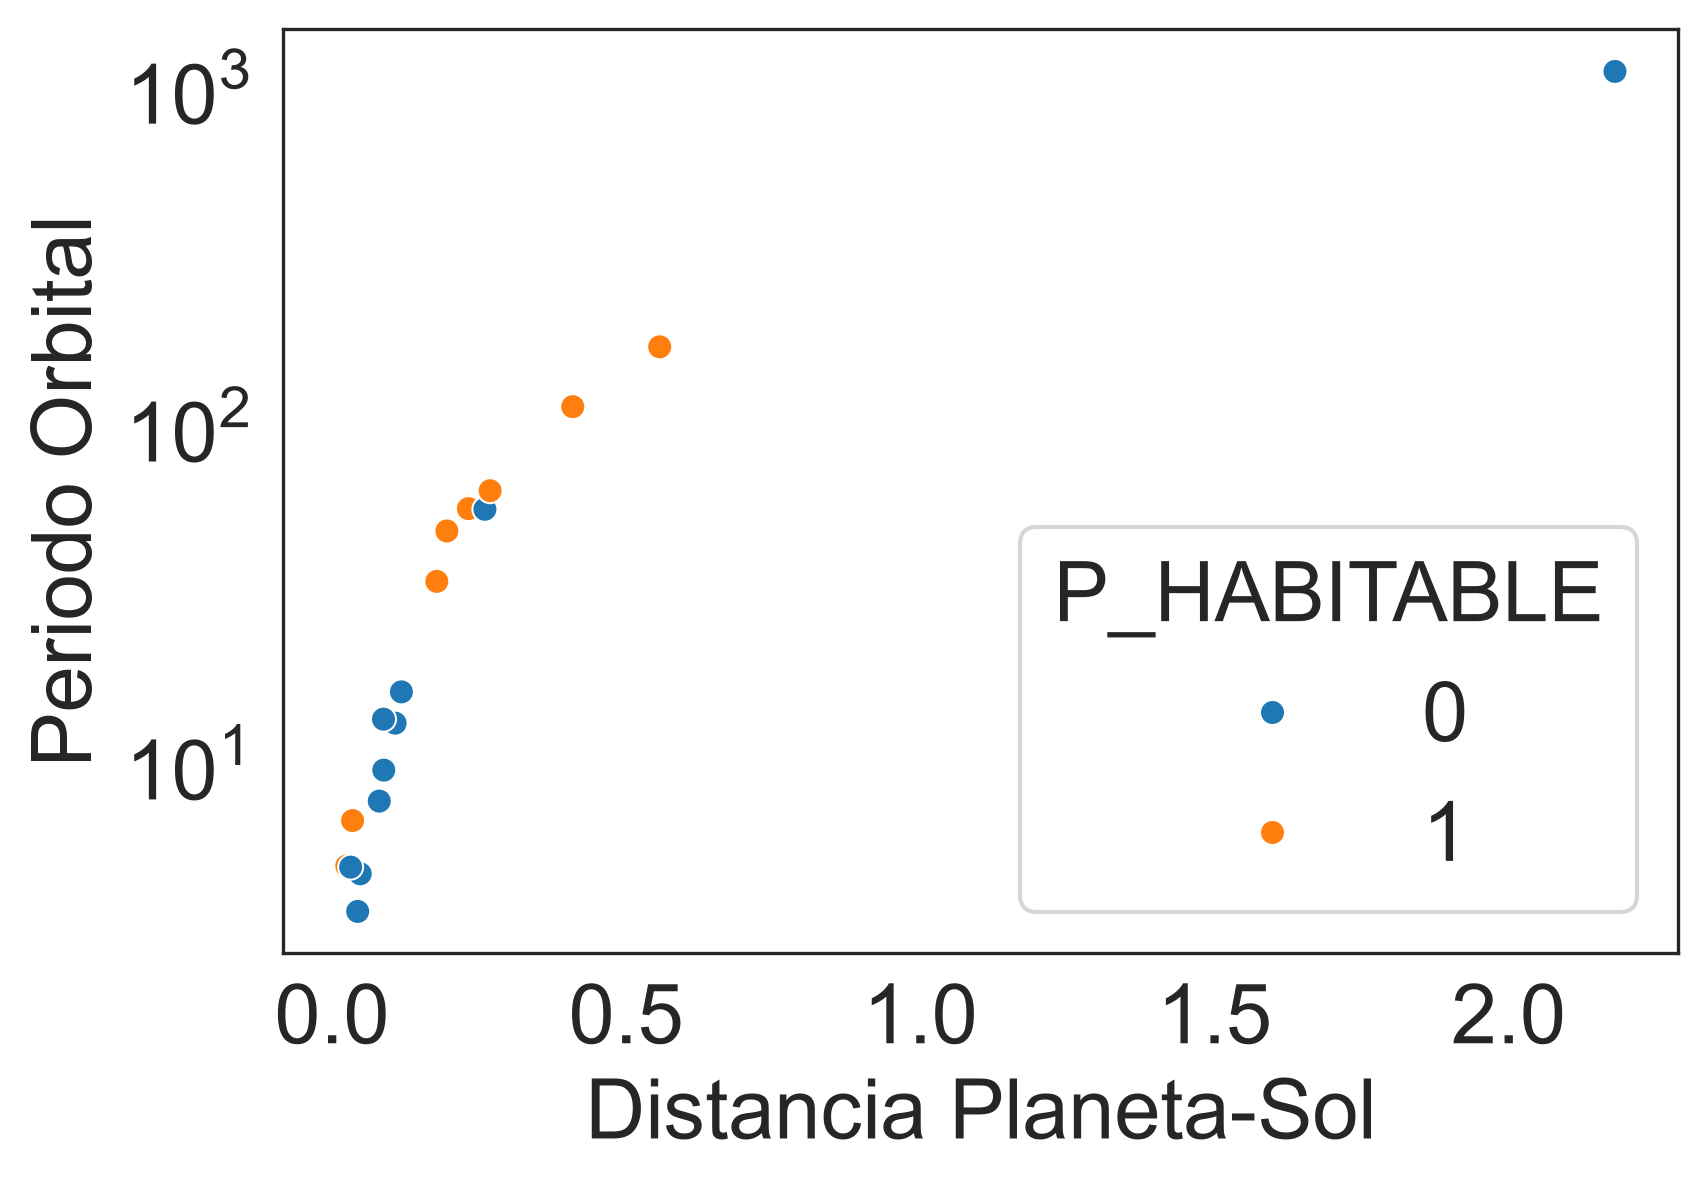

In [149]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=LearningSet, x="P_DISTANCE", y="P_PERIOD", hue="P_HABITABLE")

plt.yscale("log")

plt.xlabel("Distancia Planeta-Sol")
plt.ylabel("Periodo Orbital")

plt.show()

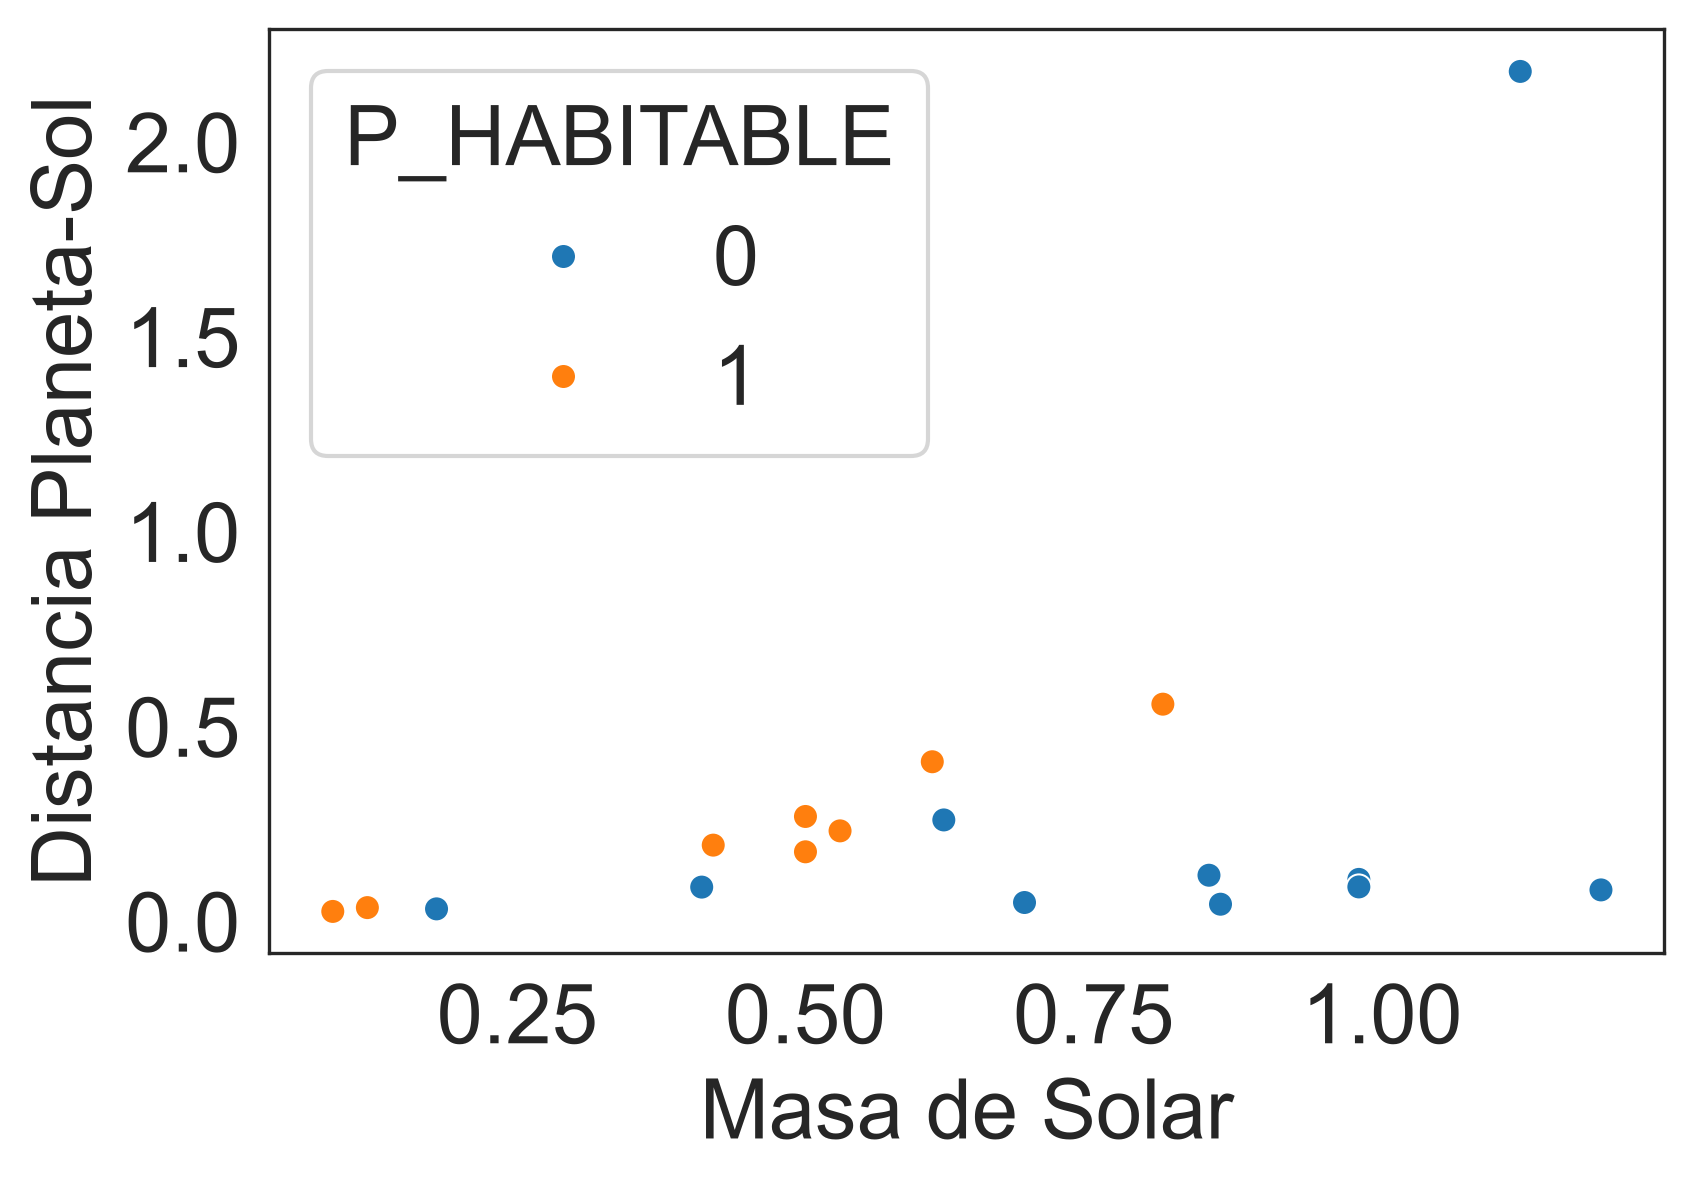

In [150]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=LearningSet, x="S_MASS", y="P_DISTANCE", hue="P_HABITABLE")

plt.xlabel("Masa de Solar")
plt.ylabel("Distancia Planeta-Sol")

plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


**Las clases no parecen estar separadas "fácilmente". Pues si se observa desde un modo lineal o algun ajuste de curva como se ha realizado hasta el momento, no pareciera haber correlación con nada. Por otra parte, si es posible observar algún tipo de comportamiento si se mira el mapa de datos 2D y se separa en secciones.**

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [151]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [152]:
TrainSet =  LearningSet.iloc[:13,:]  

TestSet = LearningSet.iloc[13:,:]

In [153]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [154]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [155]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [156]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='str')

In [157]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [158]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [159]:
ytrain

0     0
1     0
2     0
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: P_HABITABLE, dtype: int64

### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [160]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


In [161]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

print("Score de entrenamiento: ", model.score(Xtrain, ytrain)) #Evaluamos el modelo con el conjunto de entrenamiento
print("Score de prueba: ", model.score(Xtest, ytest)) #Evaluamos el modelo con el conjunto de prueba
# Lo ideal es que el Score de prueba sea similar al de entrenamiento, si es mucho menor, el modelo está sobreajustado (overfitting).

Score de entrenamiento:  1.0
Score de prueba:  0.6


### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/) 

In [162]:
print(Xtrain.shape)
print(Xtrain.columns.tolist())  # si es un DataFrame de pandas

(13, 3)
['S_MASS', 'P_PERIOD', 'P_DISTANCE']


In [163]:
print(model.n_features_in_)

3


In [164]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

#Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### Visualización de sklearn

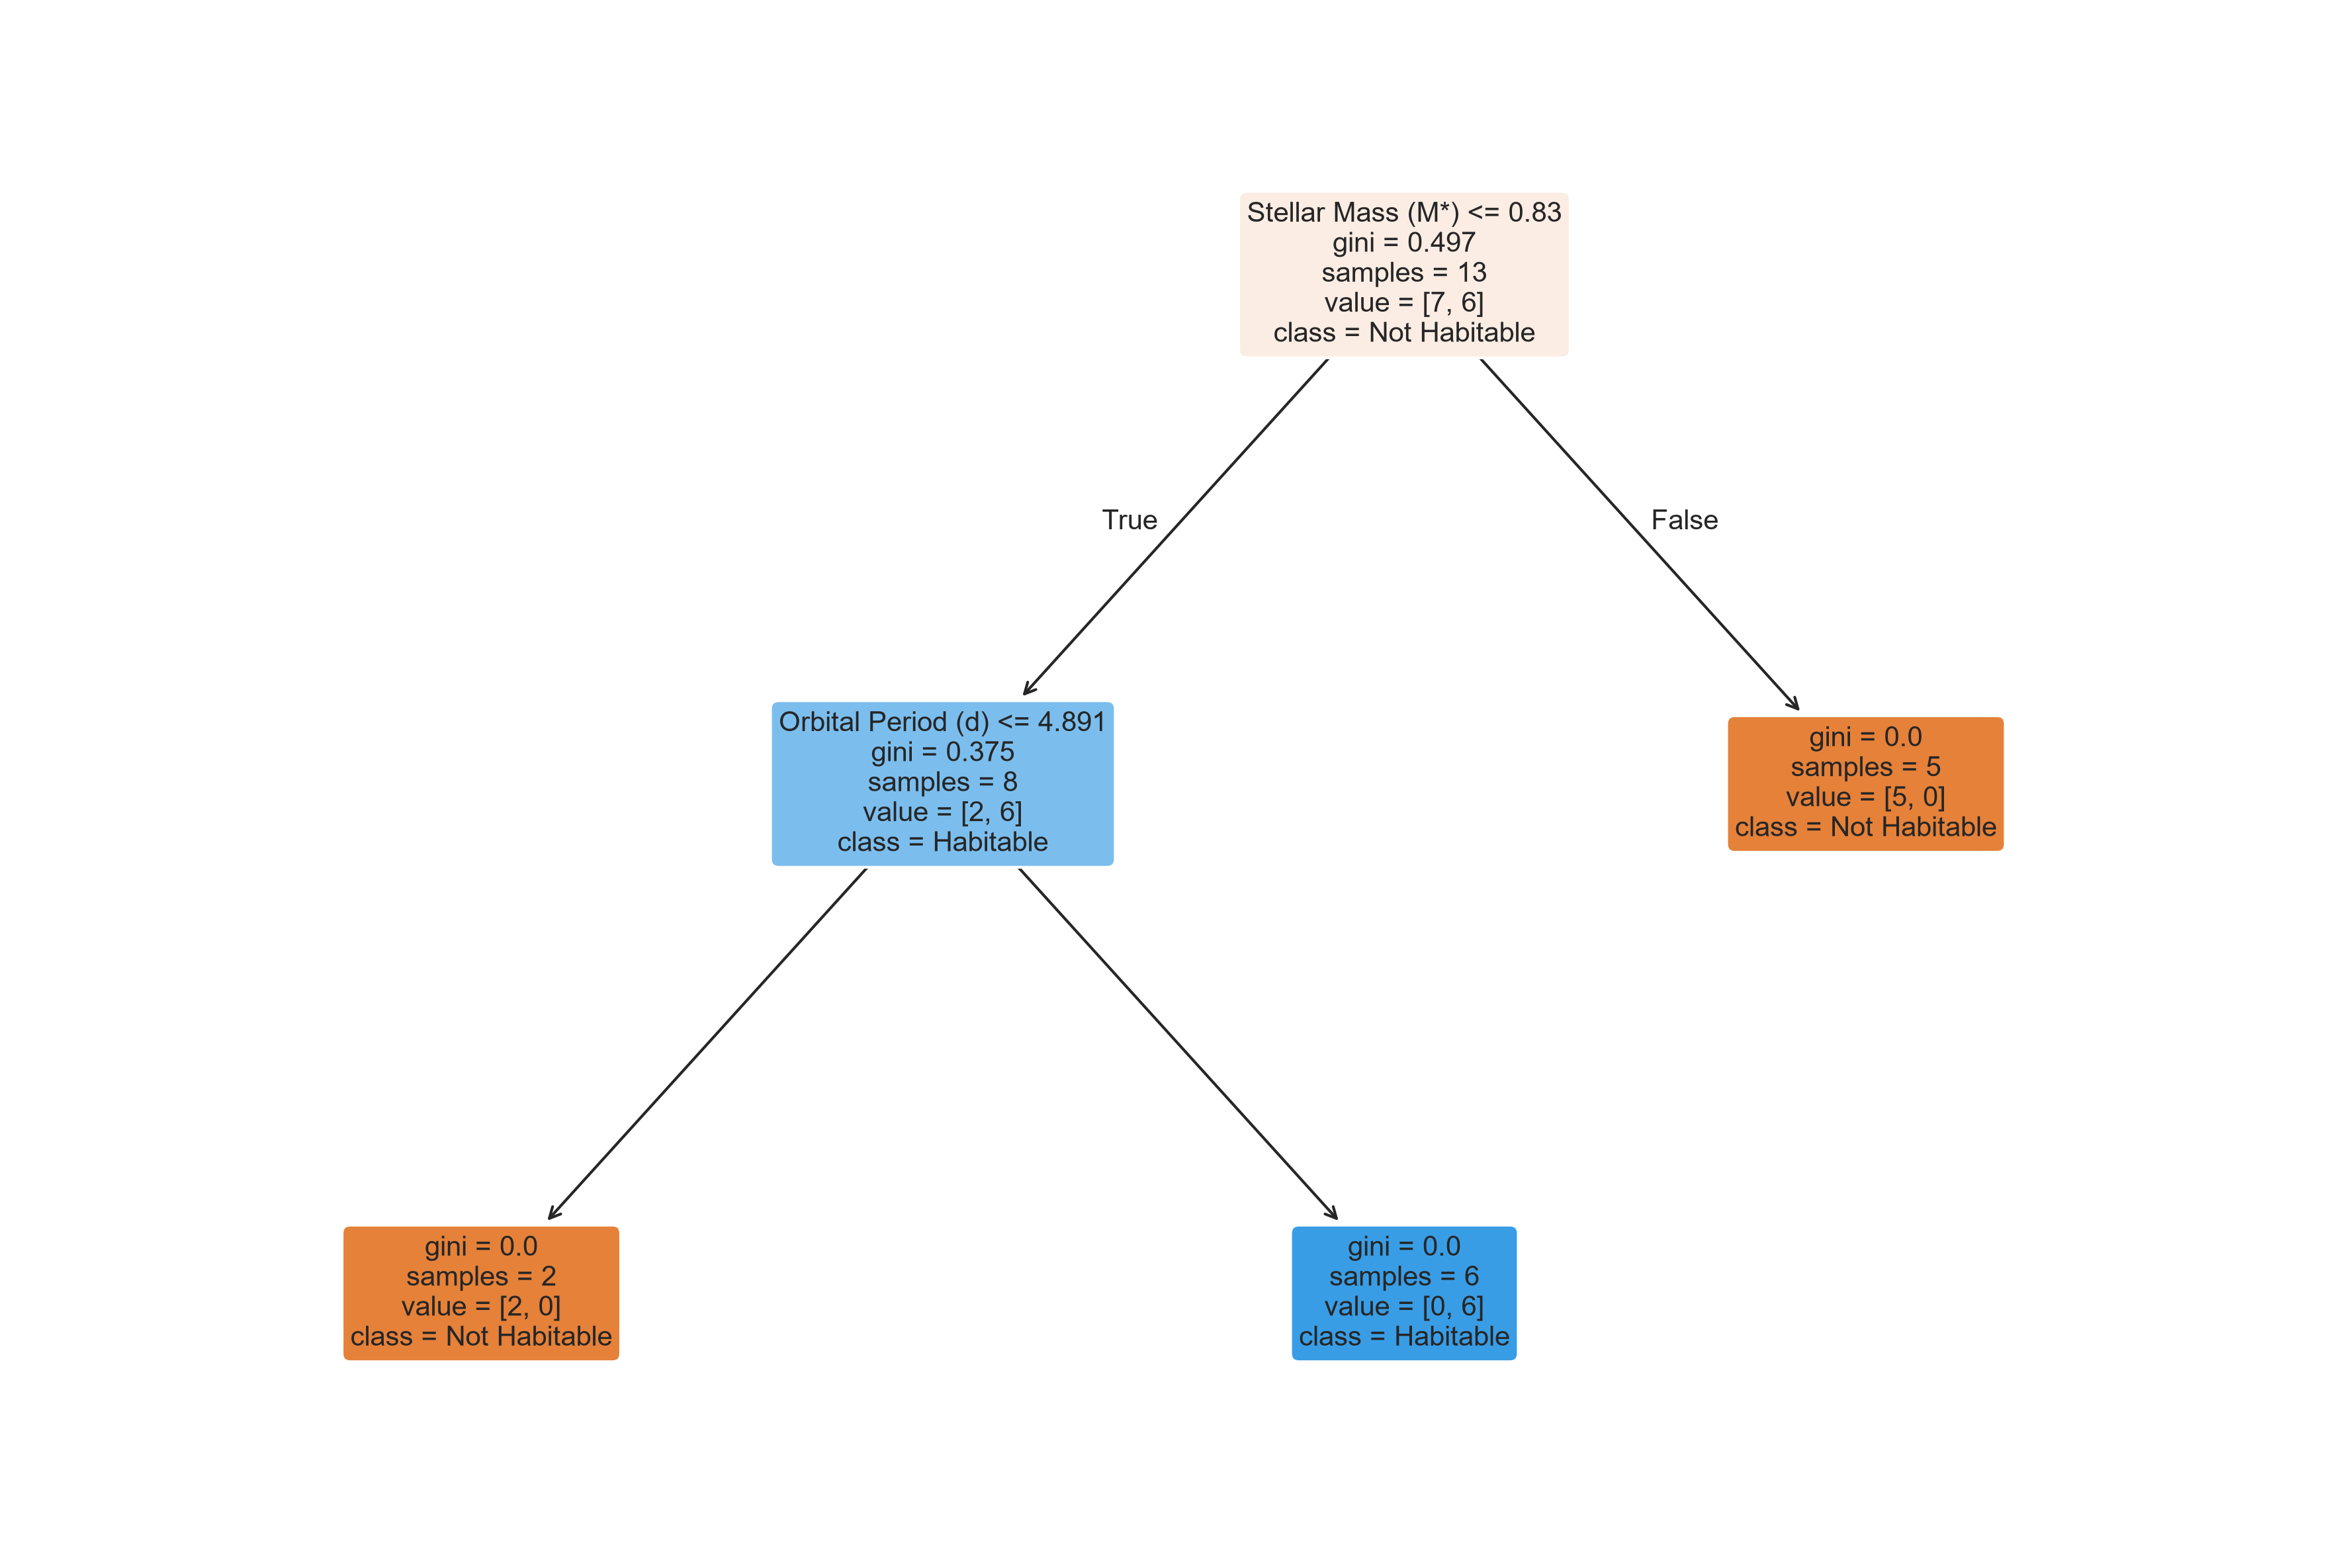

In [165]:
from sklearn import tree

plt.figure(figsize=(15,10))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

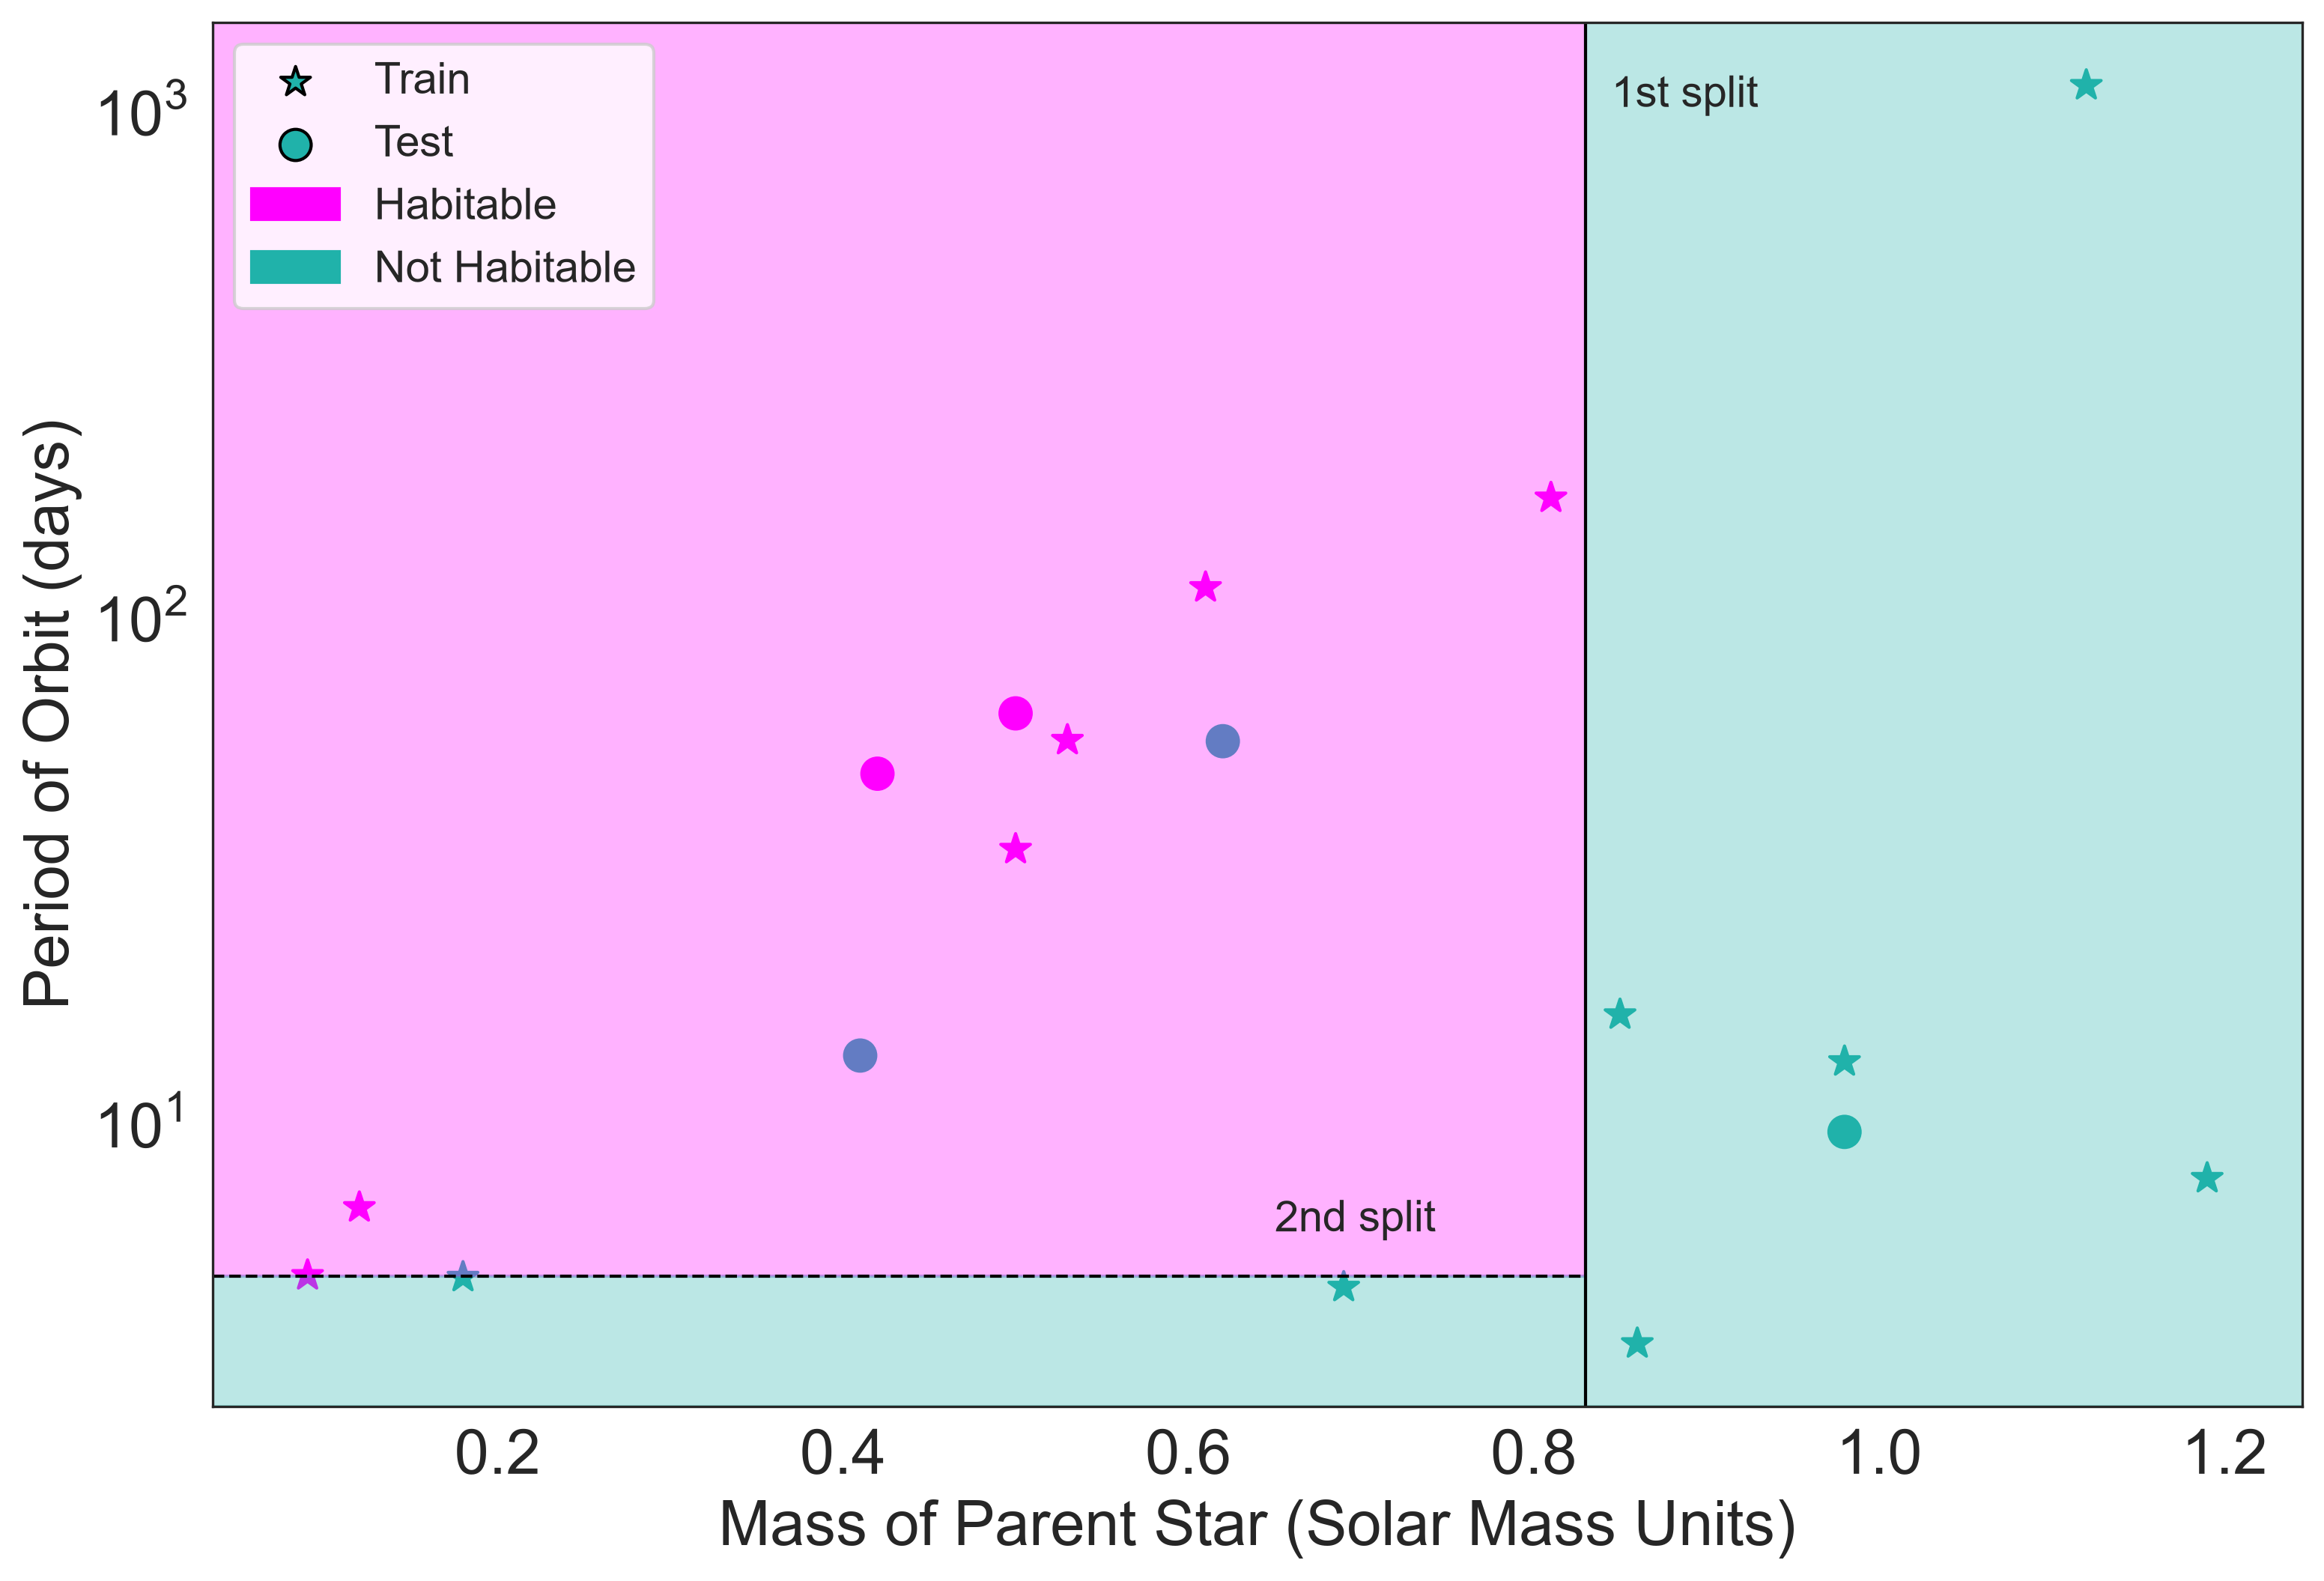

In [166]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta 
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

### usando la métricas de sklearn, podemos encontrar el accuracy


In [167]:
import sklearn.metrics as metrics


In [168]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [169]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [170]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [171]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?

**Sí. Como se comprobó en el accuracy score de (xtrain, ytrain), el resultado fue del 100%. Sin embargo, esto no es necesariamente bueno, pues al no declarar hiperparámetros el árbol continuo hasta encontrar nodos puros, lo que puede resultar en un overfitting.**

2. ¿Qué ocurre en el conjunto de prueba?

**En el caso del conjunto de prueba se observa que el 60% de los datos fueron acertados por el modelo entrenado, lo cual representa un buen valor considerando la poca cantidad de datos. Además, un valor menor al 100% es totalmente esperable y normal, pues si el test score fuese del 100% no podríamos confiar en este, ya que los datos suelen tener ruido y variabilidad.**

3. ¿Qué variable aparece en la raíz del árbol?

**La variable que aparece en la raíz del árbol es la masa solar, lo que significa que de las 3 variables en mano, el modelo decidió que la que nos separaba mejor las clases en el primer paso era la masa del sol que orbita el planeta.**

4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?

**Me parece que el árbol es simple, pues aunque sean pocos datos, el sistema definió su resultado con tan solo dos cortes, considerando que además no se declararon hiperparametros y que se dejó al sistema realizar sus ajustes necesarios hasta que el modelo de entrenamiento cumpliera con un score del 100%**

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [172]:
from sklearn.model_selection import train_test_split

# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:] 
TestSet2 = LearningSet.iloc[:5,:]


#TrainSet2, TestSet2 = train_test_split(LearningSet, test_size=5, random_state=3)


### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [173]:
TrainSet2

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1
10,Kepler-296 e,0.50,34.142110,0.178202,1
11,Kepler-705 b,0.53,56.056054,0.231926,1
12,Kepler-445 c,0.18,4.871229,0.031746,0
13,HD 104067 b,0.62,55.806000,0.260000,0
14,GJ 4276 b,0.41,13.352000,0.087613,0


In [174]:
TestSet2

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0


In [175]:
Xtrain2 = TrainSet2.drop(["P_NAME", "P_HABITABLE"], axis=1)

Xtest2 = TestSet2.drop(["P_NAME", "P_HABITABLE"], axis=1)

In [176]:
Xtrain2

,S_MASS,P_PERIOD,P_DISTANCE
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107
10,0.50,34.142110,0.178202
11,0.53,56.056054,0.231926
12,0.18,4.871229,0.031746
13,0.62,55.806000,0.260000
14,0.41,13.352000,0.087613


In [177]:
ytrain2 = TrainSet2.P_HABITABLE

ytest2 = TestSet2.P_HABITABLE

In [178]:
Xtest2

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408


In [179]:
ytrain2

5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
13    0
14    0
15    1
16    0
17    1
Name: P_HABITABLE, dtype: int64

In [180]:
model2 = DecisionTreeClassifier(random_state = 3)

model2.fit(Xtrain2, ytrain2)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

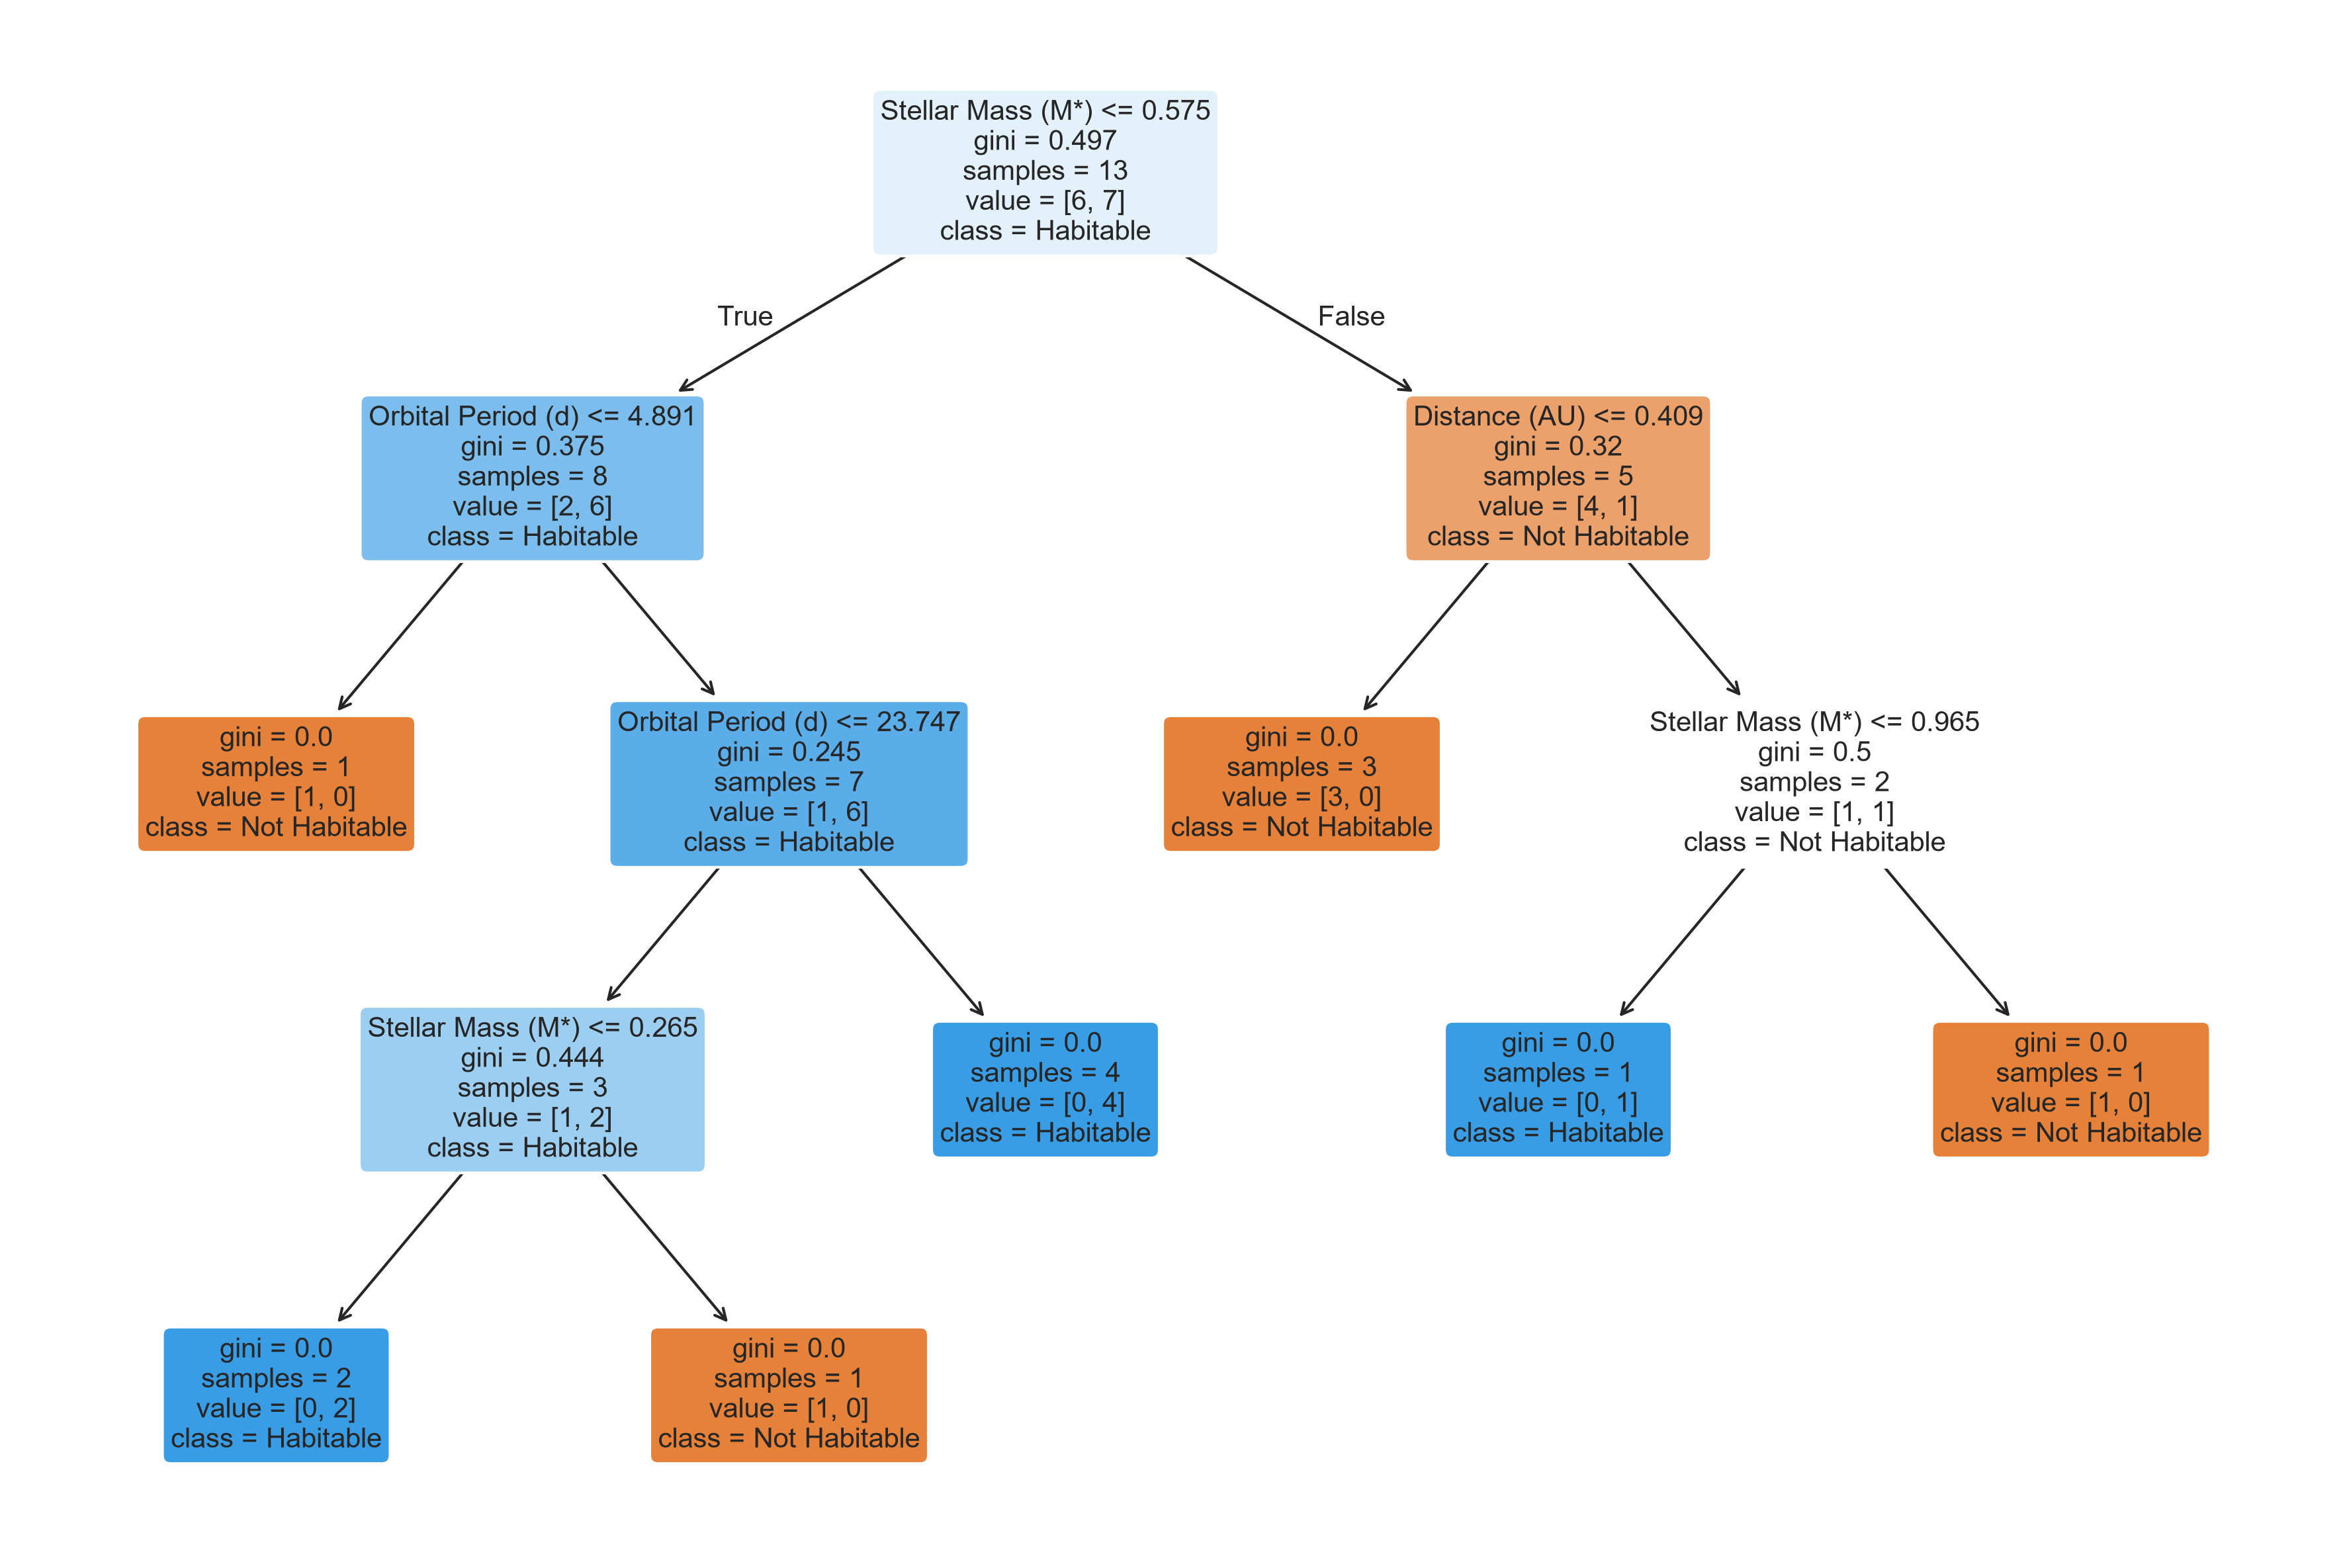

In [181]:
from sklearn import tree

plt.figure(figsize=(15,10))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model2,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

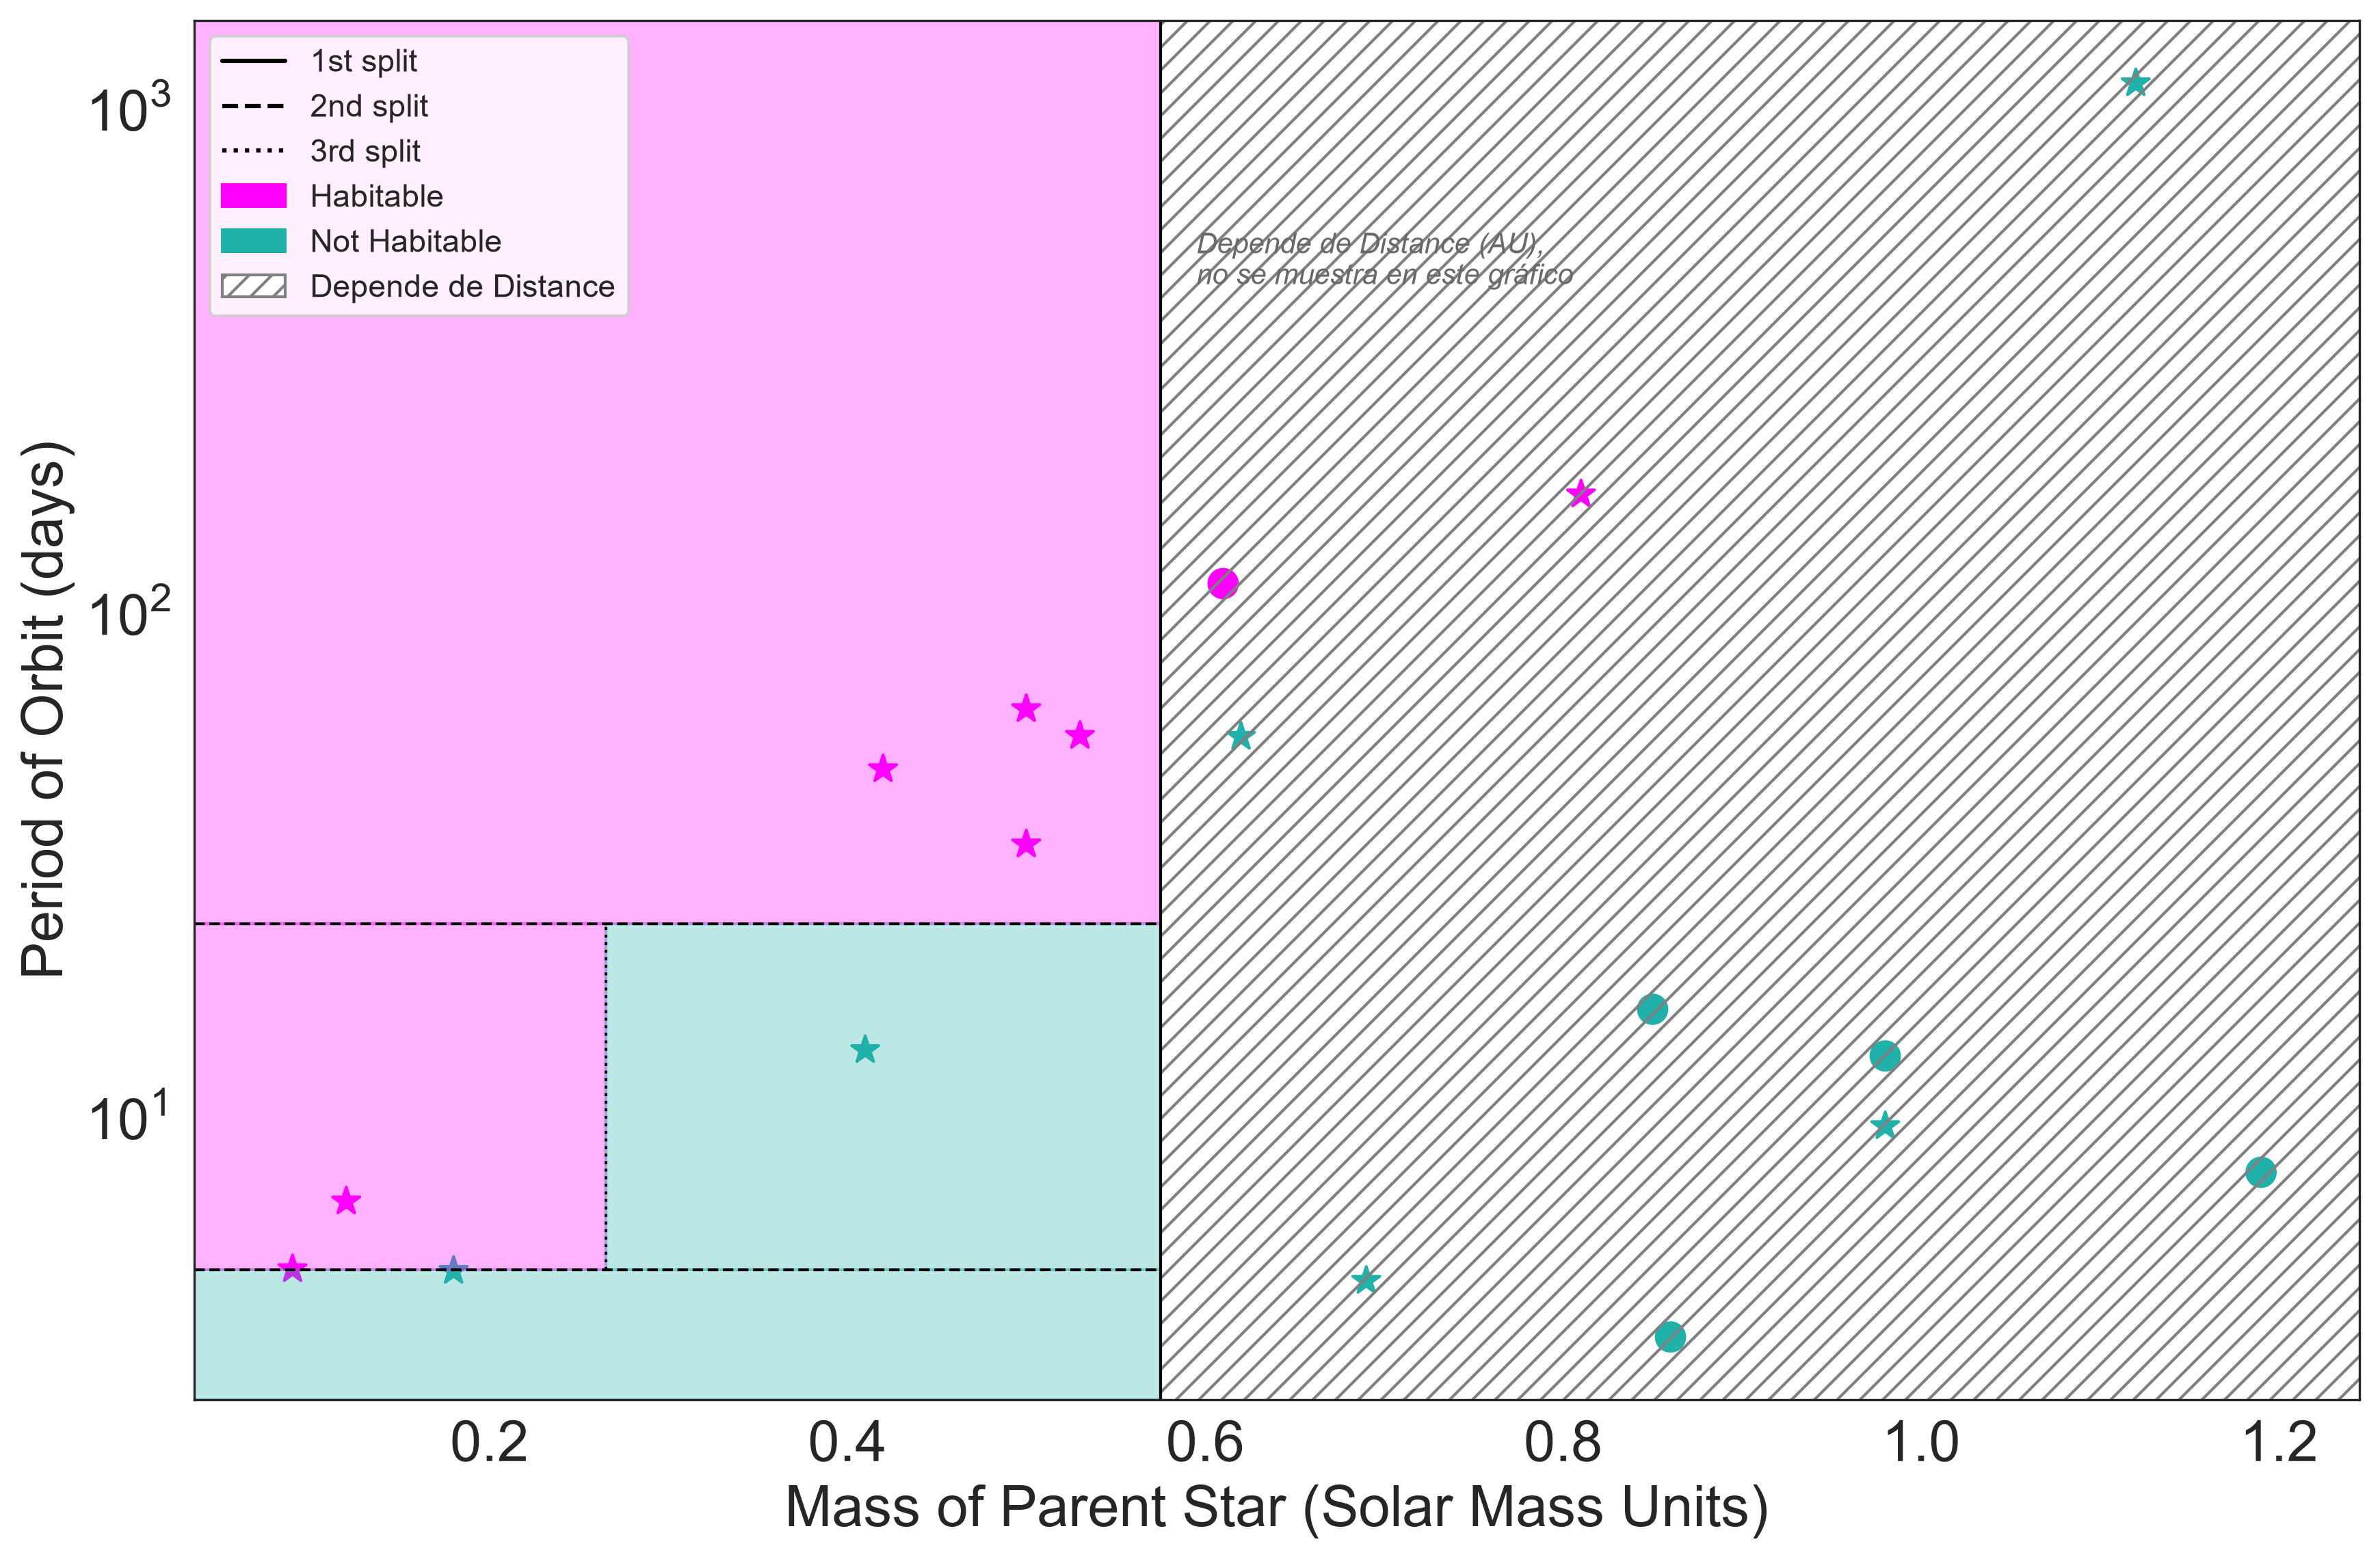

In [182]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

# Puntos de entrenamiento y prueba
plt.scatter(TrainSet2['S_MASS'], TrainSet2['P_PERIOD'], marker='*',
            c=TrainSet2['P_HABITABLE'], s=100, cmap=cmap, label='Train')

plt.scatter(TestSet2['S_MASS'], TestSet2['P_PERIOD'], marker='o',
            c=TestSet2['P_HABITABLE'], s=100, cmap=cmap, label='Test')

plt.yscale('log')
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Splits de la rama izquierda (Masa <= 0.575) — solo depende de masa y período
mass_split_1 = 0.575
period_split_1 = 4.891
period_split_2 = 23.747
mass_split_2 = 0.265

# --- Líneas de corte de la rama izquierda ---
frac_mass1 = (mass_split_1 - xlim[0]) / (xlim[1] - xlim[0])

plt.axvline(x=mass_split_1, linewidth=1, ls='-', c='k', label='1st split')
plt.axhline(y=period_split_1, xmin=0, xmax=frac_mass1, linewidth=1, ls='--', c='k', label='2nd split')
plt.axhline(y=period_split_2, xmin=0, xmax=frac_mass1, linewidth=1, ls='--', c='k')
plt.vlines(x=mass_split_2, ymin=period_split_1, ymax=period_split_2, linewidth=1, ls=':', color='k', label='3rd split')

# --- Regiones de la rama izquierda ---

# Período <= 4.891 -> Not Habitable
r1 = mpatches.Rectangle((xlim[0], ylim[0]), mass_split_1 - xlim[0], period_split_1 - ylim[0],
                         fill=True, color='#20B2AA', alpha=0.3)

# 4.891 < Período <= 23.747, Masa <= 0.265 -> Habitable
r2 = mpatches.Rectangle((xlim[0], period_split_1), mass_split_2 - xlim[0], period_split_2 - period_split_1,
                         fill=True, color='#FF00FF', alpha=0.3)

# 4.891 < Período <= 23.747, Masa > 0.265 -> Not Habitable
r3 = mpatches.Rectangle((mass_split_2, period_split_1), mass_split_1 - mass_split_2, period_split_2 - period_split_1,
                         fill=True, color='#20B2AA', alpha=0.3)

# Período > 23.747 -> Habitable
r4 = mpatches.Rectangle((xlim[0], period_split_2), mass_split_1 - xlim[0], ylim[1] - period_split_2,
                         fill=True, color='#FF00FF', alpha=0.3)

# --- Región de la rama derecha (Masa > 0.575) ---
# Depende de Distance, no de Período -> se deja marcada con rayado, sin color de clase
r5 = mpatches.Rectangle((mass_split_1, ylim[0]), xlim[1] - mass_split_1, ylim[1] - ylim[0],
                         fill=False, hatch='///', edgecolor='gray', linewidth=0)

for r in [r1, r2, r3, r4, r5]:
    ax.add_patch(r)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Nota aclaratoria dentro del gráfico
plt.text(mass_split_1 + 0.02, ylim[1]*0.3, 'Depende de Distance (AU),\nno se muestra en este gráfico',
          fontsize=10, color='dimgray', style='italic')

# --- Leyenda ---
bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
hatchpatch = mpatches.Patch(facecolor='white', edgecolor='gray', hatch='///', label='Depende de Distance')

leg = ax.get_legend()
plt.legend(handles=[
    plt.Line2D([0], [0], color='k', label='1st split'),
    plt.Line2D([0], [0], color='k', ls='--', label='2nd split'),
    plt.Line2D([0], [0], color='k', ls=':', label='3rd split'),
    magentapatch, bluepatch, hatchpatch
], loc='upper left', fontsize=11)



plt.tight_layout()
plt.show()

In [183]:
ypred2 = model2.predict(Xtest2)
ypred

array([1, 1, 1, 0, 1])

In [184]:
metrics.accuracy_score(ytest2, ypred2) #test score

1.0

In [185]:
metrics.accuracy_score(ytrain2, model2.predict(Xtrain2)) #train score

1.0

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

**Sobre los árboles de decisión obtenidos hay varias cosas que mencionar, partiendo sobre la diferencia en la profundidad, pues mientras la primera tenia un nivel 2, esta tiene nivel 4. Que haya un nivel más profundo implica que al grupo de entrenamiento le costo más poder llegar a una solución óptica (en este caso, debido a la falta de hiperparametros, la solución sería la que le de un train score de 100%) con el conjunto de datos que tenía. Otra diferencia importante es que mientras el primer árbol llego a un resultado óptimo solamente dividiendo entre masa solar y periódo orbital, el segundo árbol realizó divisiones en masa solar, periódo orbital y distancia planeta-sol, lo que resulta en que este conjunto de divisiones no pueda ser gráfico como el primer árbol, pues tenemos 3 variables aparte de la habitabilidad del planeta, que es lo que se busca predecir.**

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento? 

**El accuracy es del 100%. Sin embargo, esto es de esperar, pues no definimos hiperparametros que detengan el entrenamiento del árbol de decisión, así que este seguirá hasta llegar al 100%.**

- ¿Y en el conjunto de prueba?

**En el conjunto de prueba el accuracy también es del 100%, aunque esto no necesariamente representa algo bueno, pues aunque se logró una predicción perfecta de los datos, estos no necesariamente indican que el modelo haya aprendido a modelar este conjunto de datos, ya que como se mencionó antes es normal que el conjunto de datos tenga outliers o variaciones, lo que nos asegura que nunca es esperable que el accuracy del test sea del 100% cuando el modelo es realmente bueno.**

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?

**No. Lo respondí en la pregunta anterior :p.**


### Conclusiones

- Que puede concluir respecto a al ejercicio?

**Mis conclusiones son las siguientes:**
1. **El modelo resultante depende mucho de cual es el conjunto de datos determinados para entrenamiento y para prueba.**
2. **Un accuracy de entrenamiento y de prueba del 100% no necesariamente son buenos resultados, pues pueden significar que hubo overfitting o un mal modelamiento de los datos de prueba, pues no determinó variaciones ni outliers.**
3. **Para lograr un resultado óptimo y más preciso será necesario hacer uso de hiperparametros, los cuales dependen del conjunto de datos que tenemos y de nuestro objetivo.**

- Cambian los resultados dependiendo del set de datos que utilizamos?

**Si. Cambia tanto el camino del árbol de decisión como el accuracy del modelo aplicado al conjunto de datos.**

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

**No necesariamente. Primero que todo, esto dependerá del conjunto de datos que utilicemos como entrenamiento y prueba. Es probable que en varios conjuntos de árboles distintos esta si sea habitable, pero no en todos, pues como ya se vió antes los cortes pueden ser distintos o depender de varios parámetros. En el caso del primer árbol, la habitabilidad de la Tierra dependerá del periódo orbital y la masa del Sol, mientras que en el segundo árbol dependerá tanto de estos mismo parámetros como también de la distancia planeta-sol, aclarando que no necesariamente los valores de la masa solar-periódo orbital en ambos árboles será el mismo.**

## k-Nearest Neighbors 

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [186]:
from sklearn import neighbors 
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [187]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [188]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [189]:
model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [190]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [191]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [192]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [193]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [194]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [195]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    
    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles 

C:\Users\benja\AppData\Local\Temp\ipykernel_16304\4252254111.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
C:\Users\benja\AppData\Local\Temp\ipykernel_16304\4252254111.py:11: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\


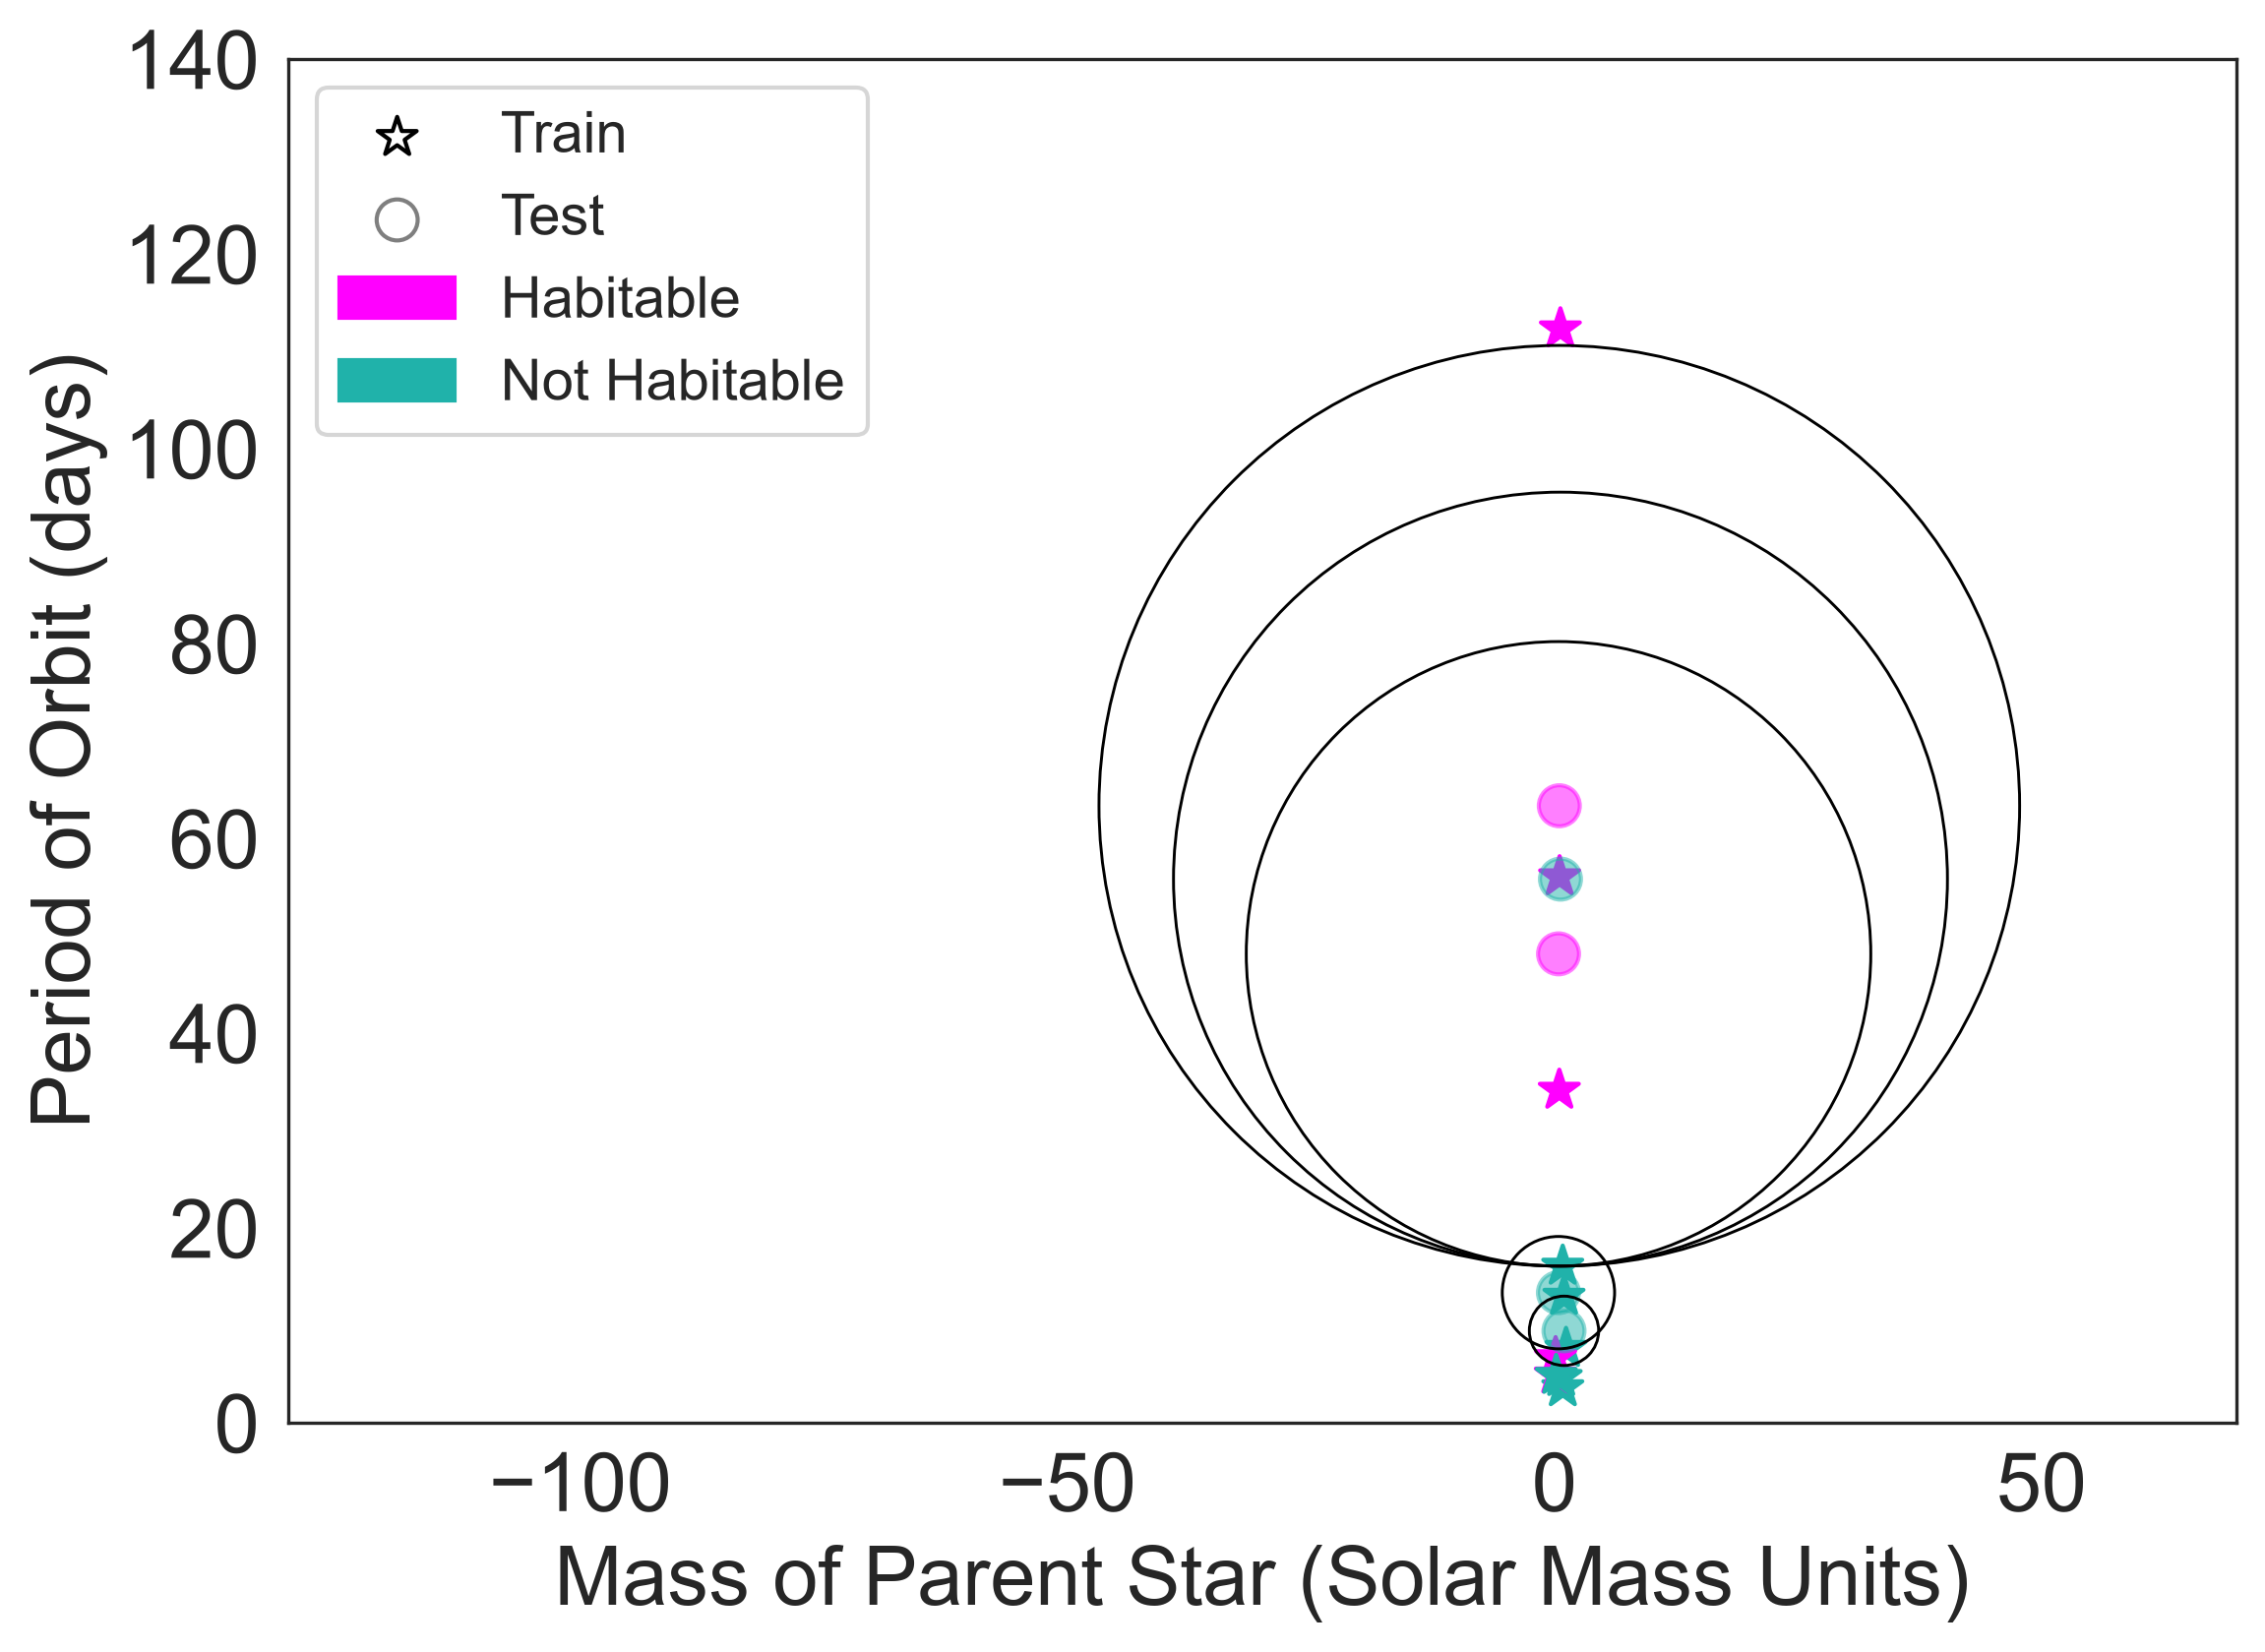

In [196]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)


plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

**Lo que puedo mencionar sobre este gráfico es que el conjunto de datos de prueba no considera como vecinos a los otros datos de prueba por más que estos sean el más próximo a este, por lo tanto una idea clave podría ser utilizar un conjunto de datos de prueba que no este tan cerca entre sí. Otro punto a mencionar es que debido a que en algunos casos el tercer planeta más cercano está en realidad bastante lejano, lo que resulta en esa circunferencia de radio demasiado grande que achata al gráfico y que hace parecer que todo el conjunto de datos está en un eje vertical (las masas solares aparentes varían desde casi 0 a 2 app, mientras que el eje horizontal en este gráfico tiene un ancho de 200).**

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [197]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [198]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [199]:
scaledXTrain = scaler.transform(Xtrain)

In [200]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [201]:
scaledXtest = scaler.transform(Xtest) # 

In [202]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [212]:
model.fit(scaledXTrain[:,:2], ytrain)
scaledytestpred = model.predict(scaledXtest[:,:2])

In [213]:
scaledytestpred, ytest.values

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [216]:
print(metrics.accuracy_score(ytrain, model.predict(scaledXTrain[:,:2]))) 

print(metrics.accuracy_score(ytest, model.predict(scaledXtest[:,:2]))) 

0.8461538461538461
0.8


In [217]:
model.kneighbors(scaledXtest[:,:2])

(array([[0.2500478 , 0.53900086, 1.00570768],
        [0.47721081, 0.66005572, 0.79614695],
        [0.16494121, 0.57079985, 1.00501058],
        [0.06956397, 0.35230123, 0.38378203],
        [0.34256727, 0.35245873, 1.07701084]]),
 array([[11, 10,  1],
        [10, 12,  6],
        [11, 10,  3],
        [ 4,  0,  1],
        [11, 10, 12]]))

In [218]:
for i in range(len(TestSet)):
    print(model.kneighbors(scaledXtest[:,:2])[0][i,2])

1.0057076822074733
0.7961469534072081
1.0050105812138872
0.3837820313273946
1.0770108415685602


C:\Users\benja\AppData\Local\Temp\ipykernel_16304\333698586.py:4: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a = plt.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker='*', facecolor='None',\
C:\Users\benja\AppData\Local\Temp\ipykernel_16304\333698586.py:7: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a = plt.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker='o', facecolor='None',\


Text(0, 0.5, 'Period of Orbit (escalado, RobustScaler)')

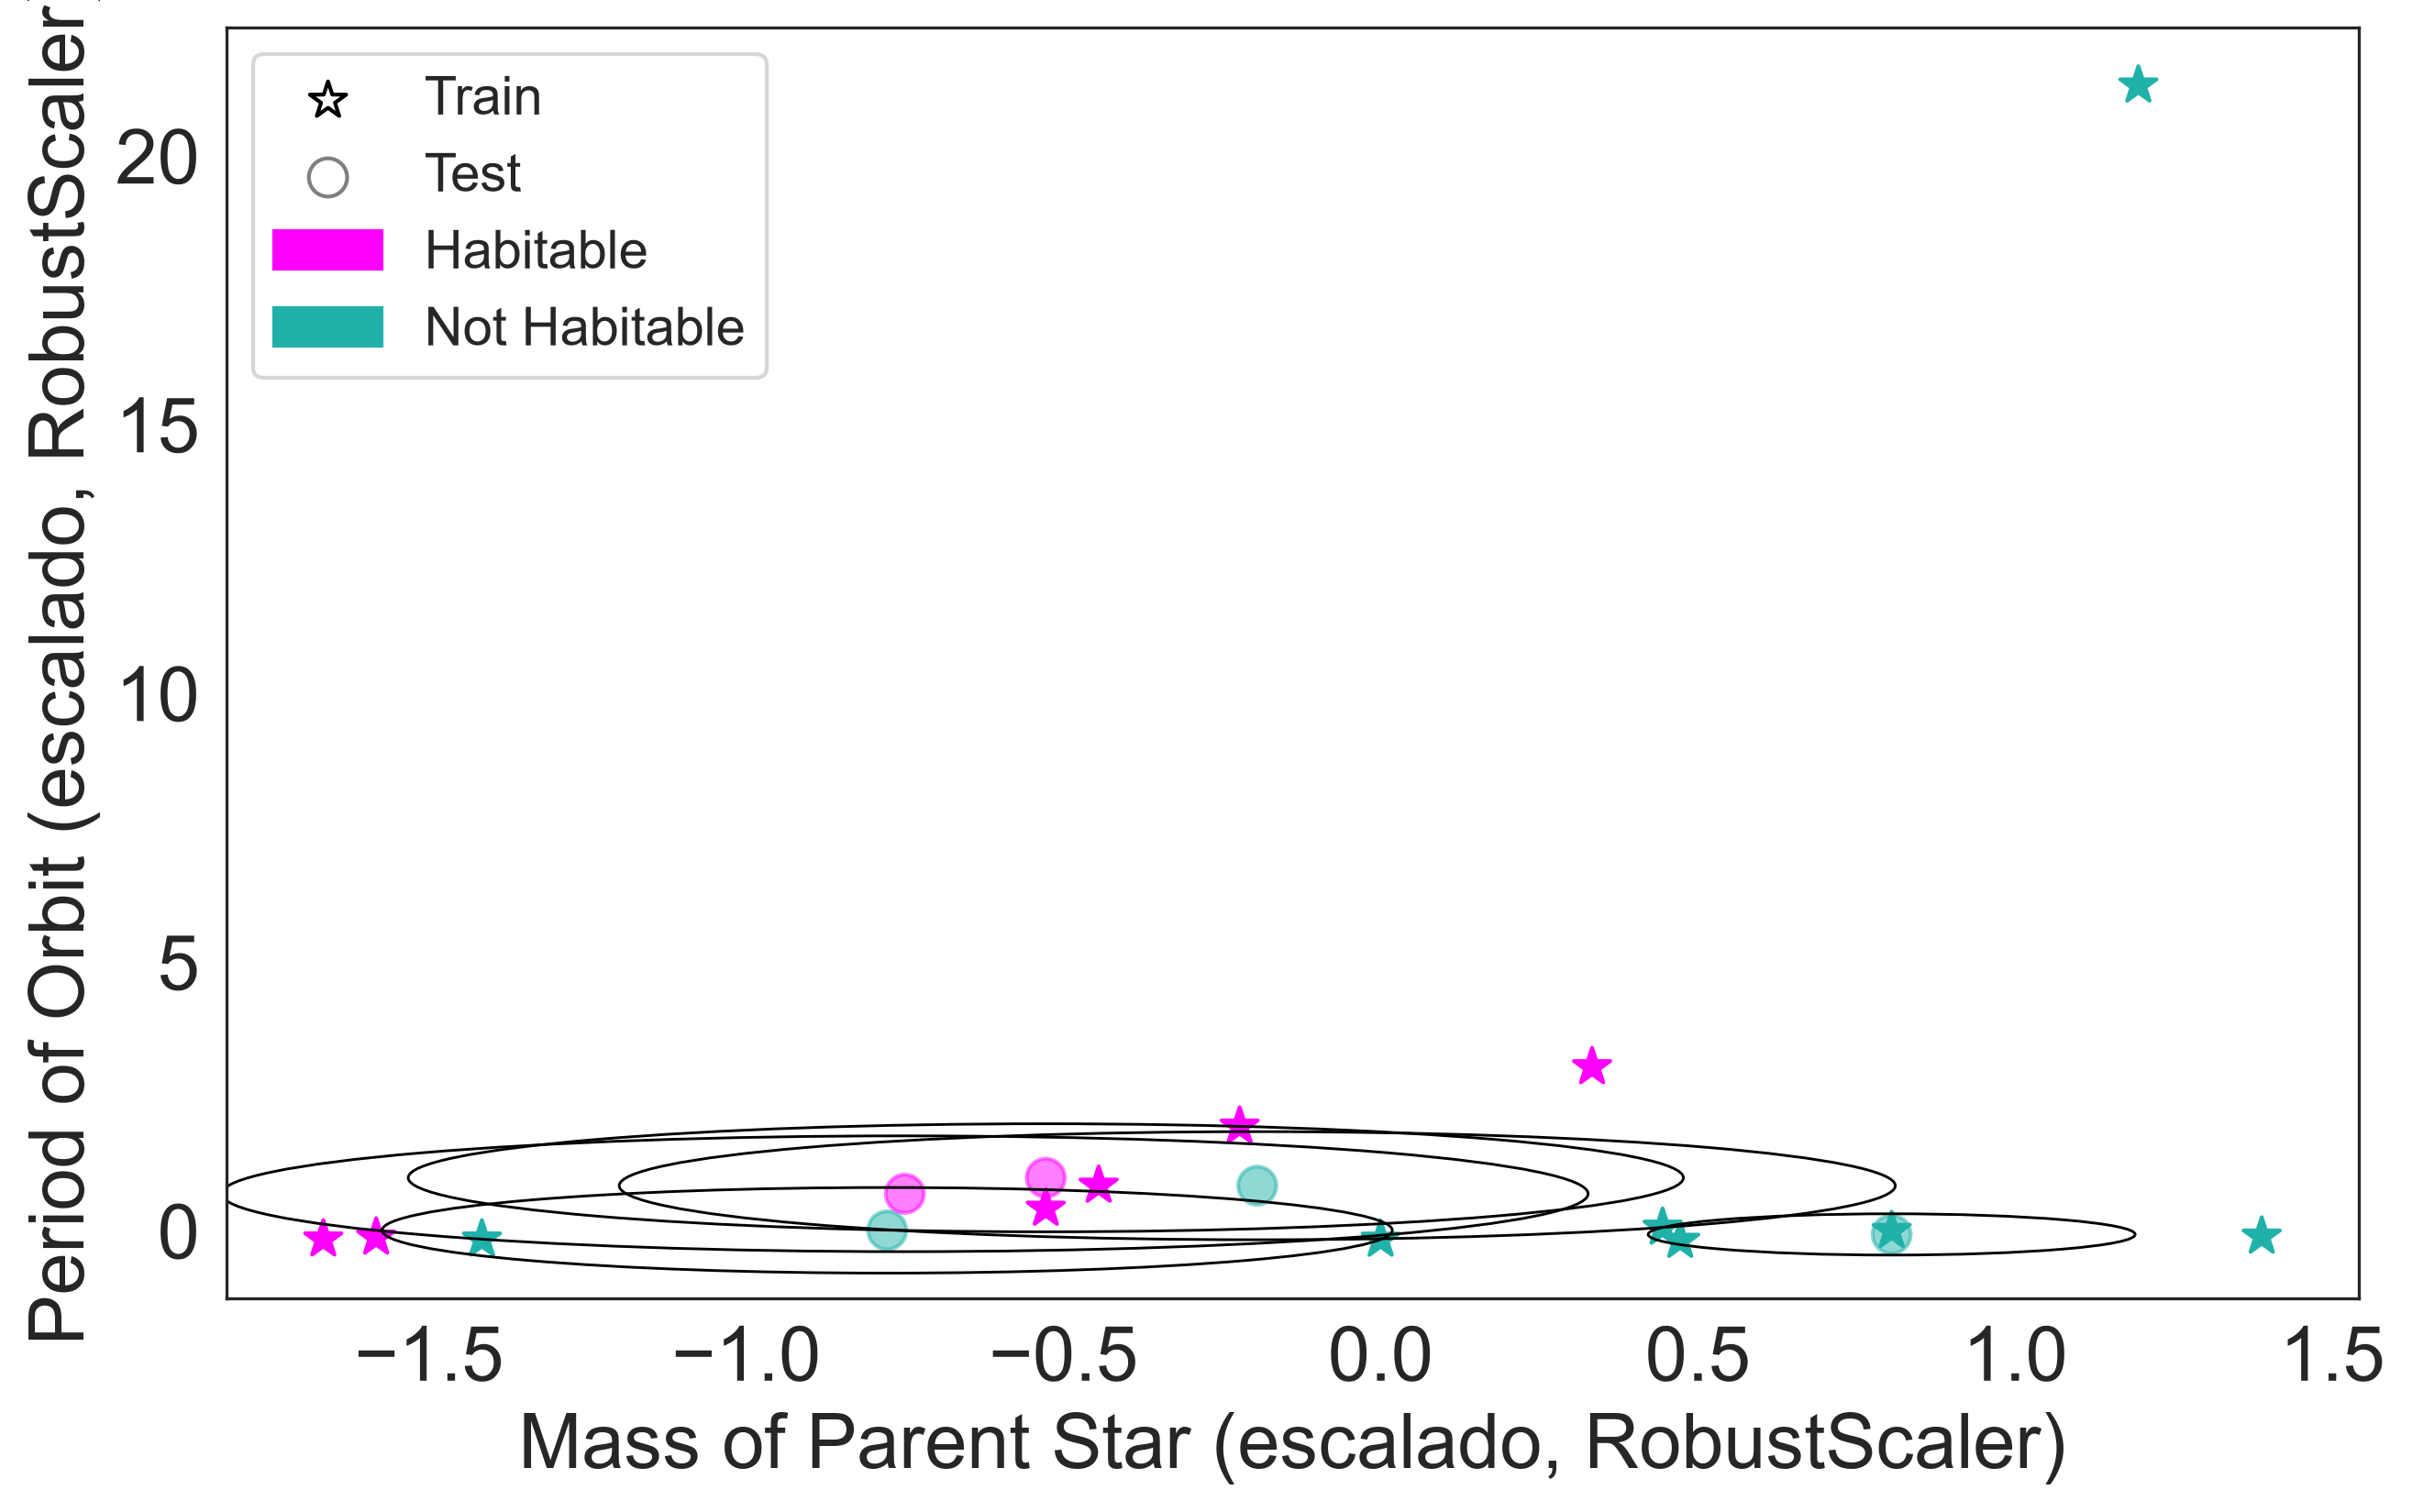

In [227]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

a = plt.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker='*', facecolor='None',\
            c=TrainSet['P_HABITABLE'], s=100, label='Train', cmap=cmap)

a = plt.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker='o', facecolor='None',\
            c=TestSet['P_HABITABLE'], s=100, label='Test', cmap=cmap, alpha=0.5)

for i in range(len(TestSet)):
    circle1 = plt.Circle((scaledXtest[i, 0], scaledXtest[i, 1]),
                          model.kneighbors(scaledXtest[:, :2])[0][i, 2],\
                          lw=0.7, edgecolor='k', facecolor='none')
    plt.gca().add_artist(circle1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')

plt.legend(handles=[leg.legend_handles[0], leg.legend_handles[1], magentapatch, bluepatch],\
           loc='upper left', fontsize=14)

plt.xlabel('Mass of Parent Star (escalado, RobustScaler)')
plt.ylabel('Period of Orbit (escalado, RobustScaler)')


**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [235]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [236]:
model.fit(scaledXTrain, ytrain)
ytestpred0 = model.predict(scaledXtest)

ytestpred0, ytest.values

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [238]:
print(metrics.accuracy_score(ytrain, model.predict(scaledXTrain))) 

print(metrics.accuracy_score(ytest, model.predict(scaledXtest)))

0.8461538461538461
0.8


In [239]:
model.kneighbors(scaledXtest)

(array([[0.29115916, 0.69239567, 1.2569941 ],
        [0.67779313, 0.7237294 , 0.82338099],
        [0.2564508 , 0.74697027, 1.25174822],
        [0.12395053, 0.41553168, 0.42393826],
        [0.36402651, 0.39388867, 1.37741822]]),
 array([[11, 10,  1],
        [10, 12,  6],
        [11, 10,  3],
        [ 4,  1,  0],
        [10, 11,  6]]))

### Preguntas 

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

**No, árbol de decisión no tiene este mismo problema, pues en este se utilizó el escalado solamente por fines visuales en los datos, pero no cambia el resultado. El árbol de decisión lo que hace es determinar si la variable que se busca predecir es más común por sobre o por debajo de un cierto umbral.**

- Compare las fortalezas y debilidades de DT y kNN

**DT y kNN son modelos que funcionan de manera distinta. El modelo de kNN necesita de un escalado adecuado de los datos para poder realizar una predicción razonable, mientras que DT no lo necesita, lo que lo vuelve más sencillo. Por otra parte, DT es bastante fácil de interpretar, pues en los casos anteriores vimos como se tomaba la decisión de un corte, de que variable dependía y cual fue todo el camino para llegar al resultado, mientras que kNN no nos entrega más información de las decisiones tomadas para llegar al resultado. Una debilidad de DT es que es bastante subceptible a los cambios si se modifican los grupos de entrenamiento y prueba, y aunque kNN también lo es, no pareciera influenciar tan fuertemente como a DT.**

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

**La diferencia conceptual es que DT busca una variable que sea influyente en un grupo de datos, define un punto intermedio entre ambos y realiza cortes, separando siempre entre un resultado A y un resultado B, es decir, siempre va haciendo divisiones de dos en dos, hasta acortar el mapa de modo que los conjuntos en cada división pertenezcan de la manera más eficiente dentro del grupo correspondiente (habitable o no habitable en este caso). Por otra parte, kNN simplemente toma los datos de prueba y analiza que vecinos cercanos a estos son similares a ellos. Aquí no necesariamente se analiza el mapa entero, sino que se rellena por secciones circulares (en el caso de DT son secciones rectangulares).**

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

**Porque el acc del entrenamiento solo nos dice hasta que punto de precisión fue entrenado el modelo con el conjunto de datos en mano, pero precisión en este caso puede resultar en un overfitting. Así que también necesitamos información del acc de test, que nos comprueba que tan bien fue entrenado el modelo aplicando el resultado a un conjunto de datos distinto. Supongamos en el caso de DT, un modelo sobreajustado puede tener cortes tan precisos que en vez de haber realizado un análisis por sección, simplemente memorizó en que lugar estaban los puntos de entrenamiento, así que al probar con los datos de prueba podría arrojar un resultado no esperado.**

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

**Porque kNN evalua según la distancia euclidiana, en donde el resultado de esta distancia depende tanto de la separación de los datos en el eje vertical, como en el horizontal. El conjunto de datos debe de ser escalado para que ambos ejes tengan distancias equivalentes, de modo que el modelo no priorice el valor entregado por la separación de un eje por sobre el otro. Por otra parte, DT no hace esto, sino que simplemente toma el conjunto de datos como esta y separa el mapa en distintas secciones, sin importar la distancia entre ellas.**

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?

**Para este conjunto de datos yo elegiría el modelo kNN, pues es el que arrojó un resultado más realista, tanto en train acc como en test acc. Para este conjunto de datos, en el primer primer caso de estudio DT llegó a un resultado sin siquiera utilizar P_DISTANCE, es decir, sólo basó su modelo en S_MASS y P_PERIODO, y aunque en el resto de modelos esto no fue así, lo que me da a entender es que para este conjunto de datos es posible llegar a un resultado óptimo y rápido con solamente estas dos características, mientras que la tercera característica aporta información, pero que puede ser deducida desde las otras dos. Por ende, y observando el gráfico de S_MASS y P_PERIODO, concluyo que es difícil separar este conjunto de datos en cortes rectangulares, pues observamos planetas habitables y no habitables en lugares de masa solar y periodo orbital cercanos entre sí (por lo que es probable que dependa más fuertemente de otros factores que no se consideran aquí). Un conjunto de datos modelado en base a circulos de distintas circunferencias podría ser más efectivo para este pequeño conjunto de datos.**